In [10]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [11]:
df = pd.read_csv("Nassau Candy Distributor.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [12]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name',
       'Sales', 'Units', 'Gross Profit', 'Cost'],
      dtype='object')

In [13]:
# ✅ CLEAN COLUMN NAMES (PERMANENT FIX)
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.lower()

In [14]:
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'country/region', 'city', 'state/province',
       'postal_code', 'division', 'region', 'product_id', 'product_name',
       'sales', 'units', 'gross_profit', 'cost'],
      dtype='object')

In [15]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   row_id          10194 non-null  int64  
 1   order_id        10194 non-null  object 
 2   order_date      10194 non-null  object 
 3   ship_date       10194 non-null  object 
 4   ship_mode       10194 non-null  object 
 5   customer_id     10194 non-null  int64  
 6   country/region  10194 non-null  object 
 7   city            10194 non-null  object 
 8   state/province  10194 non-null  object 
 9   postal_code     10194 non-null  object 
 10  division        10194 non-null  object 
 11  region          10194 non-null  object 
 12  product_id      10194 non-null  object 
 13  product_name    10194 non-null  object 
 14  sales           10194 non-null  float64
 15  units           10194 non-null  int64  
 16  gross_profit    10194 non-null  float64
 17  cost            10194 non-null 

,row_id,customer_id,sales,units,gross_profit,cost
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,134468.961154,13.908537,3.791838,9.166451,4.742087
std,2942.898656,20231.483007,11.341020,2.228317,6.643740,5.061647
min,1.000000,100006.000000,1.250000,1.000000,0.250000,0.600000
25%,2549.250000,117212.000000,7.200000,2.000000,4.900000,2.400000
50%,5097.500000,133550.000000,10.800000,3.000000,7.470000,3.600000
75%,7645.750000,152051.000000,18.000000,5.000000,12.250000,5.700000
max,10194.000000,192314.000000,260.000000,14.000000,130.000000,130.000000


In [16]:
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'country/region', 'city', 'state/province',
       'postal_code', 'division', 'region', 'product_id', 'product_name',
       'sales', 'units', 'gross_profit', 'cost'],
      dtype='object')

In [17]:
df.isnull().sum()

row_id            0
order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_id       0
country/region    0
city              0
state/province    0
postal_code       0
division          0
region            0
product_id        0
product_name      0
sales             0
units             0
gross_profit      0
cost              0
dtype: int64

In [18]:
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True, errors='coerce')
df['ship_date'] = pd.to_datetime(df['ship_date'], dayfirst=True, errors='coerce')

df = df.dropna(subset=['order_date', 'ship_date'])

df['lead_time'] = (df['ship_date'] - df['order_date']).dt.days

df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'country/region', 'city', 'state/province',
       'postal_code', 'division', 'region', 'product_id', 'product_name',
       'sales', 'units', 'gross_profit', 'cost', 'lead_time'],
      dtype='object')

In [19]:
print(df.columns.tolist())

['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'country/region', 'city', 'state/province', 'postal_code', 'division', 'region', 'product_id', 'product_name', 'sales', 'units', 'gross_profit', 'cost', 'lead_time']


In [20]:
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'country/region', 'city', 'state/province',
       'postal_code', 'division', 'region', 'product_id', 'product_name',
       'sales', 'units', 'gross_profit', 'cost', 'lead_time'],
      dtype='object')

In [21]:
df.lead_time.head()

0    909
1    909
2    909
3    909
4    912
Name: lead_time, dtype: int64

In [22]:
# Replace exact column name
df = df.rename(columns={'Lead Time': 'lead_time'})

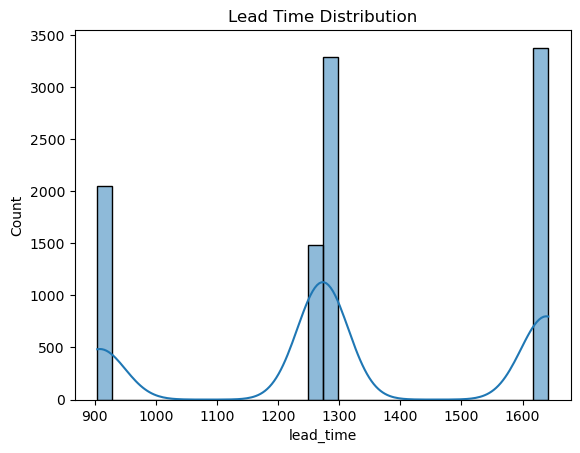

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['lead_time'], bins=30, kde=True)
plt.title("Lead Time Distribution")
plt.show()

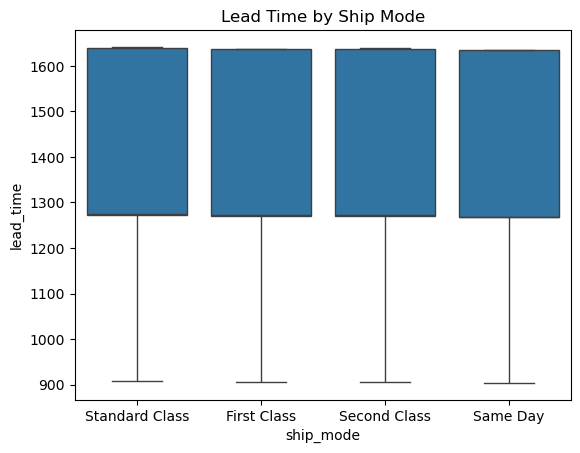

In [24]:
sns.boxplot(x='ship_mode', y='lead_time', data=df)
plt.title("Lead Time by Ship Mode")
plt.show()

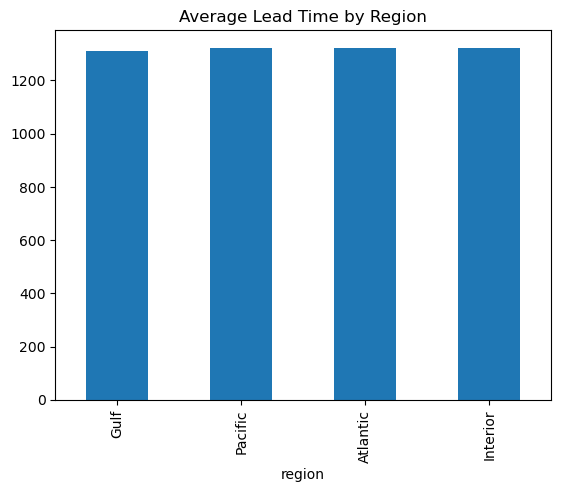

In [25]:
region_avg = df.groupby('region')['lead_time'].mean().sort_values()

region_avg.plot(kind='bar')
plt.title("Average Lead Time by Region")
plt.show()

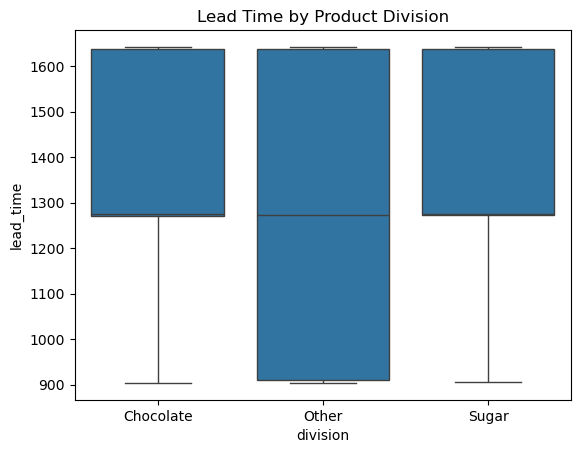

In [26]:
sns.boxplot(x='division', y='lead_time', data=df)
plt.title("Lead Time by Product Division")
plt.show()

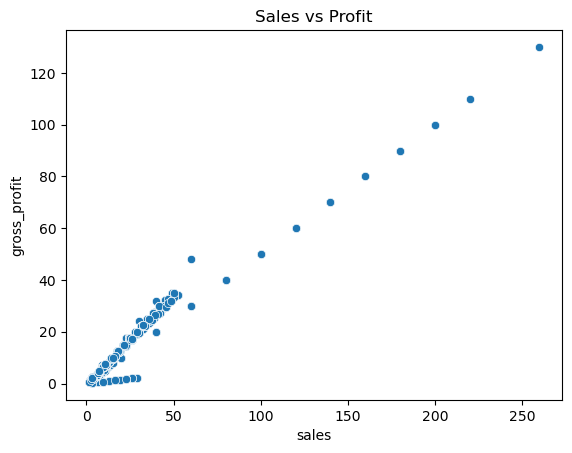

In [27]:
sns.scatterplot(x='sales', y='gross_profit', data=df)
plt.title("Sales vs Profit")
plt.show()

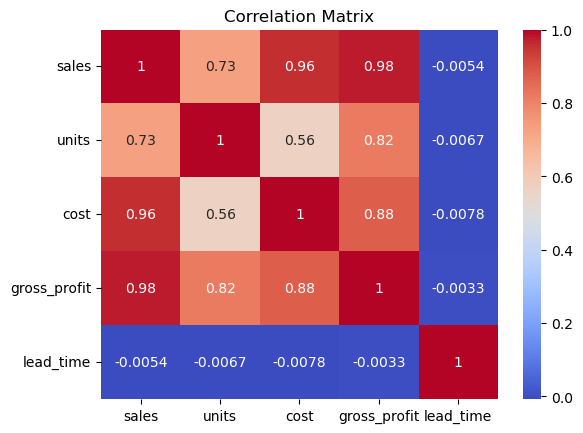

In [28]:
corr = df[['sales','units','cost','gross_profit','lead_time']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [29]:
df.sort_values(by='lead_time', ascending=False).head(10)

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,country/region,city,state/province,postal_code,division,region,product_id,product_name,sales,units,gross_profit,cost,lead_time
10183,10184,CA-2024-146626-CHO-SCR-58000,2025-12-29,2030-06-28,Standard Class,146626,Canada,St. John's,Newfoundland and Labrador,A0A,Chocolate,Atlantic,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,28.80,8,20.00,8.80,1642
10175,10176,US-2024-146626-CHO-SCR-58000,2025-12-29,2030-06-28,Standard Class,146626,United States,Anaheim,California,92804,Chocolate,Pacific,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,28.80,8,20.00,8.80,1642
7167,7168,US-2024-105851-CHO-NUT-13000,2025-03-13,2029-09-10,Standard Class,105851,United States,Denver,Colorado,80219,Chocolate,Pacific,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,6.98,2,4.98,2.00,1642
9540,9541,US-2024-139969-CHO-MIL-31000,2025-11-19,2030-05-19,Standard Class,139969,United States,College Station,Texas,77840,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,9.75,3,6.33,3.42,1642
10165,10166,US-2024-164826-CHO-TRI-54000,2025-12-28,2030-06-27,Standard Class,164826,United States,New York City,New York,10024,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,26.25,7,17.15,9.10,1642
10164,10165,US-2024-164826-CHO-FUD-51000,2025-12-28,2030-06-27,Standard Class,164826,United States,New York City,New York,10024,Chocolate,Atlantic,CHO-FUD-51000,Wonka Bar - Fudge Mallows,14.40,4,9.60,4.80,1642
10160,10161,US-2024-164826-CHO-SCR-58000,2025-12-28,2030-06-27,Standard Class,164826,United States,New York City,New York,10024,Chocolate,Atlantic,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,25.20,7,17.50,7.70,1642
8087,8088,US-2024-108560-CHO-SCR-58000,2025-07-08,2030-01-05,Standard Class,108560,United States,Kent,Washington,98031,Chocolate,Pacific,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,7.20,2,5.00,2.20,1642
10120,10121,US-2024-147956-CHO-SCR-58000,2025-12-24,2030-06-23,Standard Class,147956,United States,Seattle,Washington,98105,Chocolate,Pacific,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,21.60,6,15.00,6.60,1642
10111,10112,US-2024-128734-CHO-MIL-31000,2025-12-24,2030-06-23,Standard Class,128734,United States,Chandler,Arizona,85224,Chocolate,Pacific,CHO-MIL-31000,Wonka Bar - Milk Chocolate,13.00,4,8.44,4.56,1642


In [30]:
# Removed outliers
df = df[df['lead_time'] >= 0]
df = df[df['lead_time'] <= df['lead_time'].quantile(0.99)]

In [31]:
df

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,country/region,city,state/province,postal_code,division,region,product_id,product_name,sales,units,gross_profit,cost,lead_time
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,909
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,909
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,909
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,909
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,912
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10189,10190,US-2024-143259-CHO-MIL-31000,2025-12-30,2030-06-26,Standard Class,143259,United States,New York City,New York,10009,Chocolate,Atlantic,CHO-MIL-31000,Wonka Bar - Milk Chocolate,9.75,3,6.33,3.42,1639
10190,10191,US-2024-115427-CHO-NUT-13000,2025-12-30,2030-06-26,Standard Class,115427,United States,Fairfield,California,94533,Chocolate,Pacific,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,6.98,2,4.98,2.00,1639
10191,10192,US-2024-156720-CHO-SCR-58000,2025-12-30,2030-06-26,Standard Class,156720,United States,Loveland,Colorado,80538,Chocolate,Pacific,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,1639
10192,10193,US-2024-143259-CHO-TRI-54000,2025-12-30,2030-06-26,Standard Class,143259,United States,New York City,New York,10009,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,26.25,7,17.15,9.10,1639


In [32]:
# Encoding

categorical_cols = ['ship_mode', 'region', 'division']

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [33]:
# Feature selection

features = ['ship_mode', 'region', 'division', 'units', 'cost']
target = 'lead_time'

X = df[features]
y = df[target]

In [34]:
# Train - test - split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [36]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [37]:
pred = model.predict(X_test)

from sklearn.metrics import mean_absolute_error
print(mean_absolute_error(y_test, pred))

225.4924585140616


In [50]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

X = df[['ship_mode','region','division','units','cost']]
y = df['lead_time']

In [51]:
joblib.dump(model, "model.pkl")

['model.pkl']

In [39]:
factory_map = {
    "Wonka Bar - Nutty Crunch Surprise": "Lot's O' Nuts",
    "Wonka Bar - Milk Chocolate": "Wicked Choccy's",
    "Laffy Taffy": "Sugar Shack",
    # Add all products here
}

df['Factory'] = df['product_name'].map(factory_map)

In [40]:
factories = {
    "Lot's O' Nuts": (32.881893, -111.768036),
    "Wicked Choccy's": (32.076176, -81.088371),
    "Sugar Shack": (48.11914, -96.18115),
    "Secret Factory": (41.446333, -90.565487),
    "The Other Factory": (35.1175, -89.971107)
}

In [41]:
from math import radians, sin, cos, sqrt, atan2

def distance(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)

    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return 2 * R * atan2(sqrt(a), sqrt(1-a))

In [42]:
def simulate(product, row):
    results = []
    
    for factory, coords in factories.items():
        temp = row.copy()
        
        pred_time = rf.predict([temp])[0]
        
        results.append({
            "Factory": factory,
            "Predicted_Lead_Time": pred_time
        })
    
    return pd.DataFrame(results)

In [43]:
def recommend(product, row):
    sim = simulate(product, row)
    
    sim = sim.sort_values(by='Predicted_Lead_Time')
    
    best = sim.iloc[0]
    
    return best

In [55]:
pip install streamlit plotly pandas joblib

In [45]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

In [46]:
import pickle

with open("model.pkl", "rb") as f:
    model = pickle.load(f)

In [47]:
type(model)

sklearn.ensemble._forest.RandomForestRegressor

In [48]:
df.to_csv("cleaned_data.csv", index=False)

In [52]:
import joblib
joblib.dump(model, "model.pkl")

['model.pkl']

In [53]:
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'country/region', 'city', 'state/province',
       'postal_code', 'division', 'region', 'product_id', 'product_name',
       'sales', 'units', 'gross_profit', 'cost', 'lead_time', 'factory'],
      dtype='object')

In [54]:
df['lead_time'].mean

<bound method Series.mean of 0         909
1         909
2         909
3         909
4         912
         ... 
10189    1639
10190    1639
10191    1639
10192    1639
10193    1639
Name: lead_time, Length: 10194, dtype: int64>